<div align="center">
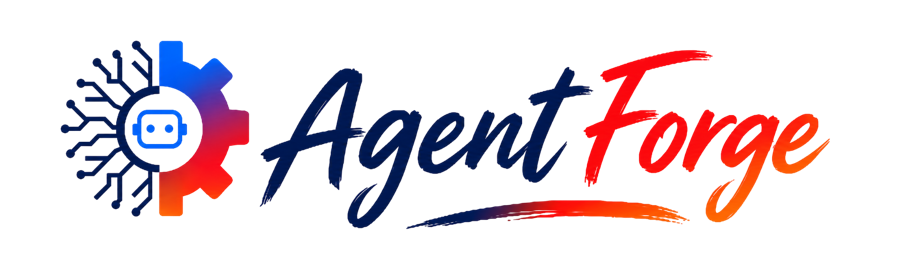

<h2>Tutorial 1: The Anatomy of an Agent</h2>
<b>Hands-on Workshop on AI Agents as Scientific Research Assistants</b><br/>
<i>Nanyang Technological University · Supported by Schmidt Sciences</i>
</div>

---

## Definition

Russell & Norvig (*Artificial Intelligence: A Modern Approach*, Ch. 2):

> *"An agent is anything that can be viewed as **perceiving** its environment
> through **sensors** and **acting** upon that environment through
> **actuators**."*

An agent is defined by a closed loop with an environment:
perceive → decide → act → perceive again.

An **LLM agent** implements this loop with a language model as the
decision-maker. The standard mechanism is **ReAct** (Yao et al., ICLR 2023),
which interleaves three steps:

- **Thought**: a reasoning trace: assess the state, plan the next step
- **Action**: a tool invocation; tools are the agent's actuators
- **Observation**: the tool result, fed back; observations are the sensors

## Case study: `mini_agent`

This tutorial dissects `mini_agent`, a complete working agent built from
minimal modules: one concern per module, most files under 40 lines.
Each section has three parts:

- **Concept**: what the element is and why the loop requires it
- **Implementation**: the module that provides it
- **Effect**: a cell that runs it

| § | Element | Classical role | Module |
|---|---------|----------------|--------|
| 1 | Language model | decision-maker | `llm/` |
| 2 | Tools | actuators | `tools/` |
| 3 | Thought | action proposal | `core/prompt` · `core/parser` |
| 4 | ReAct loop | the closed cycle | `core/agent/run.py` |
| 5 | Event log | trajectory record | `session.py` |
| 6 | Todo list | plan state | `tools/todo` |
| 7 | Memory | long-term memory | `mem/` |
| 8 | Prompt profiles | prompt templates | `prompts/` |
| 9 | Harness | CLI, UI, session management | `cli/` · `ui/` |

Summary formula:

<div align="center">

## `agent = LLM + tools + a loop`

</div>

## The element tree

The elements are not a flat list; they form a hierarchy. The organizing
fact: **per step, the model sees exactly one thing: its context** — and the
context window is finite and rebuilt on every call. Most of the machinery in
modern agents is therefore **context engineering**: mechanisms that decide
what enters this window, when, and in what form. Memory, skills, todo
snapshots, compaction, and MCP catalogs are all instances. Tools are the only
channel of action; the loop connects decision to action; the harness wraps
the whole into a usable program.

```
LLM agent
├── Model            llm/           the decision-maker (§1)
│   └── Context      what the model sees, assembled fresh each step (§3)
│       ├── System prompt    prompts/      the prompt template (§8)
│       ├── Tool catalog     TOOL_DESC     tool descriptions (§2)
│       ├── Memory           mem/          long-term memory files (§7)
│       ├── Skills           skills/       task instructions, loaded on demand (§7b)
│       └── History          State.steps   conversation history (§4)
├── Tools            tools/         actuators; the only way to act (§2)
│   └── (MCP: the standard protocol for external tool servers, §2)
├── Loop             core/agent/    ReAct: Thought → Action → Observation (§4)
└── Harness          CLI, UI, session management (§9)
    ├── Entry points     cli/          interactive / one-shot / resume
    ├── Interfaces       ui/           renderers over the event stream
    └── Session log      session.py    event log: resume, branch, replay (§5)
```

Read the tree top-down: the model can only *read context* and *name tools*;
everything else exists to control what enters the context, what happens when
a tool is named, and how humans meet the system.

Run each cell with `Shift+Enter`, top to bottom. Total time ≈ 60 minutes.

> **Running in Google Colab.** Run the setup cell below first: it installs `mini_agent` and asks for your own API key. The key stays in this runtime and is sent only to the provider you choose. Everything after that runs exactly as in the local notebook.

In [ ]:
# @title ⚙ Setup: install mini_agent and provide an API key  { display-mode: "form" }
# Run this cell first. It installs the package and configures your API key.
#
# Key handling: the key is read from Colab Secrets (left sidebar, key icon) if
# you have stored one, otherwise you are prompted for it. It stays in this
# runtime's memory and is sent only to the provider you select.

PROVIDER = "deepseek"  # @param ["deepseek", "qwen", "claude"]

import os
import subprocess
import sys

# ---- 1. install (prebuilt wheel; httpx and rich ship with Colab) ----
WHEEL = ("https://github.com/Superionichuan/agent-tutorial/raw/main/"
         "dist/mini_agent-0.1.0-py3-none-any.whl")
print("Installing mini_agent ...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", WHEEL], check=True)

# ---- 2. API key ----
SECRET_NAME = {"deepseek": "DEEPSEEK_API_KEY",
               "qwen": "QWEN_API_KEY",
               "claude": "CLAUDE_API_KEY"}[PROVIDER]

key = ""
try:                                    # Colab Secrets, if available
    from google.colab import userdata
    key = userdata.get(SECRET_NAME)
    print(f"Using {SECRET_NAME} from Colab Secrets.")
except Exception:
    pass

if not key:                             # fall back to a masked prompt
    import getpass
    print(f"No {SECRET_NAME} in Colab Secrets (sidebar > key icon).")
    key = getpass.getpass(f"Paste your {PROVIDER} API key: ").strip()

# ---- 3. configure ----
os.environ["LLM_BACKEND"] = PROVIDER
os.environ[SECRET_NAME] = key

from mini_agent.llm import create_llm

llm = create_llm()
print("Connected:", llm.model)


---
## §1 · The model alone

**Concept.** A language model maps text to text. It has no sensors and no
actuators; under the classical definition it is not an agent.

**Implementation.** `mini_agent/llm/` provides four provider backends behind
one interface (`base.py`). `create_llm()` reads `.env` and returns a callable.
Changing provider is a configuration change.

**Effect.** A routine computation: the *PV* energy of a pressure over an
atomic volume. A correct answer requires arithmetic and the CODATA conversion
constant.

In [2]:
# ▶ a two-step unit conversion, answered from parametric memory alone
q = ("A pressure of 78.4 GPa acts over an atomic volume of 11.9 cubic angstroms. "
     "What is the PV energy in eV? Reply with the number only.")
print("model:", llm(q))

EV_A3_PER_GPA = 1 / 160.21766208        # CODATA: 1 eV/A^3 = 160.21766208 GPa
print(f"truth: {78.4 * 11.9 * EV_A3_PER_GPA:.4f} eV")

model: 5.82308
truth: 5.8231 eV


The provider interface (`llm/base.py`):
```python
class BaseLLM(ABC):
    """LLM interface"""

    # cumulative token counters
    total_prompt_tokens: int = 0
    total_completion_tokens: int = 0

    # context limit (set by subclass)
    context_limit: int = 128_000

    @abstractmethod
    def call(self, prompt: str) -> str:
        pass

    def call_with_usage(self, prompt: str) -> LLMResponse:
        """Call and return token usage (subclasses may override)"""
        content = self.call(prompt)
        return LLMResponse(content=content)

    def __call__(self, prompt: str) -> str:
        return self.call(prompt)

    def reset_usage(self):
        """Reset token counters"""
        self.total_prompt_tokens = 0
        self.total_completion_tokens = 0

    @property
    def total_tokens(self) -> int:
        return self.total_prompt_tokens + self.total_completion_tokens
```


Why this shape. `llm/` is a separate package because providers change
and the interface does not: every backend implements `call(prompt) -> str`,
and token accounting lives in the base class, so the rest of the system never
mentions a vendor. The decorators each have a specific job: `@abstractmethod`
makes the provider contract enforceable (a backend missing `call` fails at
class definition, not at runtime); `@dataclass` generates the constructor and
representation for pure data records like `LLMResponse`; `@property` exposes
derived values (`total_tokens`) without a setter.

The model's answer may or may not match the reference value; nothing in
its output distinguishes the two cases. It reports no uncertainty and no
source for the constant it used. The output is not verifiable, which is the
limiting property for research use, independent of the error rate.

The remedy is structural: the model selects the computation; deterministic
code performs it. A function packaged for this purpose is called a tool.

---
## §2 · Tools

**Concept.** A tool is a function with a fixed contract: same input, same
output, result returned as text. Tools are the agent's actuators. Being
ordinary code, they are deterministic, testable, and auditable.

**Implementation.** One module per tool under `mini_agent/tools/`; the
calculator is 13 lines including input validation. `registry.py` holds two
objects: `TOOLS`, a name → function map, and `TOOL_DESC`, the plain-text
catalog shown to the model. Adding a tool requires one file and two registry
entries.

**Effect.**

The complete tool (`tools/math/calc.py`), including its input validation:
```python
def calc(expr: str) -> str:
    """Safely evaluate a math expression"""
    try:
        if not all(c in ALLOWED_CHARS for c in expr):
            return "Error: unsafe expression"
        return str(eval(expr))
    except Exception as e:
        return f"Error: {e}"
```


In [3]:
# ▶ invoke the tool: deterministic, exact
from mini_agent.tools.math import calc
calc("78.4 * 11.9 / 160.21766208")

'5.823078354084045'

In [4]:
# ▶ the registry: functions on one side, the model-facing catalog on the other
from mini_agent.tools import TOOLS, TOOL_DESC
print("registered:", ", ".join(TOOLS))
print(TOOL_DESC)

registered: calc, read_file, write_file, list_dir, bash, run_python, remember, todo_write, log

- calc(expr): evaluate a math expression
- read_file(path): read a file
- write_file(path, content): write a file
- list_dir(path): list a directory
- bash(cmd): run a bash command
- run_python(code): run Python code
- todo_write(todos): update the task list (whole-list replace). todos=[{content, status}], status: pending|in_progress|completed. For multi-step tasks write the plan first, update statuses as you go; at most one in_progress at a time
- remember(content): save an important lesson to long-term memory
- log(content): append a note to today's log



The model never receives function references. It sees only the catalog
and names a tool. The catalog is therefore the interface you design for the
model; imprecise catalog entries produce wrong tool calls.

**MCP (Model Context Protocol).** An open protocol that standardizes how
external tool servers expose tools to a model. Definition: each server
publishes a catalog of named tools with JSON-Schema-typed inputs; the agent
harness connects, discovers the catalog, and merges it into the model's
context; calls are executed by the server, outside the model.
Implementation: client-server JSON-RPC over stdio or HTTP. The registry in
this codebase is the same contract in-process. Advantages: tools become
shareable across agents and languages; capability is added by connecting a
server, not by editing agent code. Costs: every connected catalog occupies
context, and remote execution adds latency and a trust boundary.

---
## §3 · Thought

**Concept.** The Thought step of ReAct: given the goal, the catalog, and the
history, the model returns a reasoning trace plus a proposed action, as JSON
with three fields: `thought`, `action`, `args`. The model proposes; it does
not execute. Execution remains in code.

**Implementation.** `core/prompt/build.py` fills a text template with goal,
catalog, history, and memory. `core/parser/parse.py` (~20 lines) extracts
`(thought, action, args)` from the response, with a safe default for
malformed output.

**Effect.** First the template itself: the context, made physical. The five
slots are the five context sections from the element tree:

The template (`prompts/agent.md`); every context section has a slot:
```
You are an agent. Accomplish the user goal.

[Goal]
{goal}

[Tools]
{tools}
{skills}
[Memory]
{memory}

[Steps taken so far]
{history}

[Instructions]
Return JSON: {{"thought": "your reasoning", "action": "tool name or done", "args": {{"param": "value"}}}}
When the goal is complete, set action to "done" and args to {{"answer": "final answer"}}.
For arithmetic or any computation, always use the calc tool instead of mental math.
For multi-step tasks, start by writing a plan with todo_write and update statuses as you go.
```


`{goal}`, `{tools}`, `{skills}`, `{memory}`, `{history}`: policy text
around five slots. Prompt assembly is slot-filling; nothing more is hidden.
Now the mechanism in three cells:

In [5]:
# ▶ 1/3: prompt assembly: goal + tool catalog + history
from mini_agent.core.prompt import build_prompt
from mini_agent.tools import TOOL_DESC
prompt = build_prompt(goal="What is 947 * 863?", tools=TOOL_DESC, history="(none)")
print(prompt[:650])

You are an agent. Accomplish the user goal.

[Goal]
What is 947 * 863?

[Tools]

- calc(expr): evaluate a math expression
- read_file(path): read a file
- write_file(path, content): write a file
- list_dir(path): list a directory
- bash(cmd): run a bash command
- run_python(code): run Python code
- todo_write(todos): update the task list (whole-list replace). todos=[{content, status}], status: pending|in_progress|completed. For multi-step tasks write the plan first, update statuses as you go; at most one in_progress at a time
- remember(content): save an important lesson to long-term memory
- log(content): append a note to today's log


[Memo


In [6]:
# ▶ 2/3: the model returns a structured proposal (as text)
raw = llm(prompt)
print(raw[:300])

{"thought": "I need to compute 947 * 863 using the calc tool.", "action": "calc", "args": {"expr": "947 * 863"}}


The parser (`core/parser/parse.py`), which must fail safely on untrusted output:
```python
def parse_response(response: str) -> Tuple[str, str, dict]:
    """Parse the LLM response into (thought, action, args)"""
    try:
        start = response.find("{")
        end = response.rfind("}") + 1
        if start >= 0 and end > start:
            data = json.loads(response[start:end])
            return (
                data.get("thought", ""),
                data.get("action", "done"),
                data.get("args", {})
            )
    except:
        pass
    return response, "done", {}
```


In [7]:
# ▶ 3/3: parse into (thought, action, args)
from mini_agent.core.parser import parse_response
thought, action, args = parse_response(raw)
print(f"thought : {thought}")
print(f"action  : {action}")
print(f"args    : {args}")

thought : I need to compute 947 * 863 using the calc tool.
action  : calc
args    : {'expr': '947 * 863'}


At this point the model has proposed invoking `calc`; nothing has been
executed. Execution, and the repetition of this step under a budget, is the
loop.

Why `prompt/` and `parser/` are separate modules: they are the two sides of
the model boundary. Assembly runs before the call; parsing runs after, on
untrusted output, and must fail safely (note the bare fallback above). These
are the most frequently edited and most heavily tested pieces of any agent,
so each is isolated behind a one-function interface: replacing JSON parsing
with native function-calling later would change `parser/` and nothing
else.

---
## §4 · The ReAct loop

**Concept.** (Yao et al., ICLR 2023):

```
Thought_t → Action_t → Observation_t → Thought_{t+1} → …  until done
```

Reasoning maintains the plan, actions change or query the environment,
observations report the result.

**Implementation.** `core/agent/run.py`, one `for` loop. Per iteration:
`think()` (§3), a done-check, a budget-check, `execute()` for tool dispatch,
and an append of `(thought, action, result)` to `State.steps`. These triples
are the ReAct trajectory; the next prompt is assembled from them. `max_steps`
and the token ceiling are enforced by the loop, not by the model.

**Effect.** The loop source, then a compound task:

The loop body, verbatim from `core/agent/run.py`:
```python
for i in range(max_steps):
        step = i + 1
        emit("step/start", step=step)

        # 1. Think (streaming in UI mode: each LLM delta emits assistant/chunk)
        history = format_history(state)
        if conversation:
            history = f"[Earlier in this session]\n{conversation}\n[This turn]\n" + history
        on_chunk = None
        if on_event is not None:
            on_chunk = lambda text, kind="content": emit("assistant/chunk", step=step, text=text, kind=kind)
        thought, action, args = think(
            llm, goal, tool_desc, history,
            skills=skills_prompt,
            memory=memory_prompt,
            on_chunk=on_chunk,
            prompt_name=prompt_name
        )

        prompt_tokens = getattr(llm, 'total_prompt_tokens', 0)
        completion_tokens = getattr(llm, 'total_completion_tokens', 0)
        total_tokens = prompt_tokens + completion_tokens

        emit("step/think", step=step, name=name, thought=thought,
             action=action, args=args,
             tokens_in=prompt_tokens, tokens_out=completion_tokens)

        # 2. Done?
        if is_done(action):
            answer = args.get("answer") or args.get("result") or thought
            if isinstance(args, str) and args:
                answer = args
            answer = str(answer)  # the LLM may hand back int/list etc.
            emit("turn/end", answer=answer, reason="done")
            return answer
```


In [8]:
# ▶ run a compound task and trace it: one row per ReAct step
import pandas as pd
from mini_agent import Agent

def trace(agent, goal):
    """Run a goal; return (answer, trajectory table) built from the event stream."""
    ev = []
    answer = agent.run(goal, on_event=lambda t, **d: ev.append((t, d)))
    rows, cur = [], None
    for t, d in ev:
        if t == "step/think":
            cur = {"step": d["step"], "thought": d["thought"][:60],
                   "action": d["action"], "args": str(d["args"])[:36],
                   "observation": "", "tok_in": d["tokens_in"], "tok_out": d["tokens_out"]}
            rows.append(cur)
        elif t == "tool/result" and cur is not None:
            cur["observation"] = str(d["content"])[:36]
    return answer, pd.DataFrame(rows).set_index("step")

agent = Agent(use_memory=False, skills=[])
answer, tr = trace(agent, "Compute 947*863 and 12.5/0.4, then report both results.")
print("ANSWER:", answer)
tr

ANSWER: 947*863 = 817261; 12.5/0.4 = 31.25


,thought,action,args,observation,tok_in,tok_out
step,,,,,,
1,I'll compute both arithmetic results using the...,calc,{'expr': '947*863'},817261,397,147
2,First calculation done: 947*863 = 817261. Now ...,calc,{'expr': '12.5/0.4'},31.25,808,251
3,Both calculations have been completed using th...,done,{'answer': '947*863 = 817261; 12.5/0,,1241,324


Each row is one ReAct step: Thought, Action, Observation, token
usage. The trajectory is data derived from the event stream, so any analysis
you would apply to experimental data applies here: filter steps, aggregate
token cost, compare trajectories across prompts or models.

Two properties of the trace above:

1. The order of operations was not programmed anywhere; it is produced by
   the cycle.
2. The loop terminates on `done`, on `max_steps`, or on the token budget,
   all checked in code.

Changing the task string changes the trajectory; the code does not change.

---
## §5 · The event log

**Concept.** The loop does not print. It emits typed events (`tool/call`,
`turn/end`, …) through a callback. Displays subscribe to the stream; a file
can record it. One invariant is maintained: everything the model sees can be
reconstructed from the log.

**Implementation.** The loop takes an `on_event` callback. `session.py`
appends events as JSON lines and computes projections: `derive_messages()`
rebuilds the model-visible history; `fork()` copies a prefix; `replay()`
re-feeds any renderer; `compact()` writes a summary checkpoint. The file is
append-only; projections change, the record does not.

**Effect.**

In [9]:
# ▶ subscribe to the event stream (streaming deltas summarized)
events = []
agent.run("Compute 3**7.", on_event=lambda t, **d: events.append((t, d)))
chunks = sum(1 for t, _ in events if t == "assistant/chunk")
for t, d in events:
    if t == "assistant/chunk":
        continue
    print(f"{t:18s} {str(d)[:66]}")
print(f"(+ {chunks} assistant/chunk streaming events omitted)")

turn/start         {'goal': 'Compute 3**7.', 'name': 'agent'}
step/start         {'step': 1}
step/think         {'step': 1, 'name': 'agent', 'thought': "The user asked to compute
tool/call          {'step': 1, 'call_id': 's1', 'name': 'calc', 'args': {'expr': '3**
tool/result        {'step': 1, 'call_id': 's1', 'content': '2187', 'is_error': False}
step/start         {'step': 2}
step/think         {'step': 2, 'name': 'agent', 'thought': 'The calculation has been 
turn/end           {'answer': '2187', 'reason': 'done'}
(+ 134 assistant/chunk streaming events omitted)


In [10]:
# ▶ persist, discard all in-memory state, reconstruct from the file
import os
from mini_agent import SessionLog
os.path.exists("/tmp/tutorial_session.jsonl") and os.remove("/tmp/tutorial_session.jsonl")
log = SessionLog("/tmp/tutorial_session.jsonl")
agent.run("Compute 111*111.", on_event=lambda t, **d: log.append(t, **d))
del log
log = SessionLog("/tmp/tutorial_session.jsonl")
log.derive_messages()

[{'role': 'tool', 'tool_call_id': 's1', 'content': '12321'}]

In [11]:
# ▶ the log file itself: one JSON event per line, ordered by seq
for line in open("/tmp/tutorial_session.jsonl").read().splitlines()[:6]:
    print(line[:110])

{"seq": 1, "time": 1787140033.762, "type": "turn/start", "data": {"goal": "Compute 111*111.", "name": "agent"}
{"seq": 2, "time": 1787140033.763, "type": "step/start", "data": {"step": 1}}
{"seq": 3, "time": 1787140034.357, "type": "assistant/chunk", "data": {"step": 1, "text": "We", "kind": "reaso
{"seq": 4, "time": 1787140034.4, "type": "assistant/chunk", "data": {"step": 1, "text": " need", "kind": "reas
{"seq": 5, "time": 1787140034.425, "type": "assistant/chunk", "data": {"step": 1, "text": " to", "kind": "reas
{"seq": 6, "time": 1787140034.425, "type": "assistant/chunk", "data": {"step": 1, "text": " compute", "kind": 


Each line is one event with a sequence number, a timestamp, a type,
and a payload. Every view in this notebook (the message list above, the
trajectory table in §4, a future UI) is computed from lines like these.
The format is inspectable with any text tool; no database is involved.

The projection function (`session.py`), which rebuilds model-visible history from the log:
```python
    def derive_messages(self, until_seq: int | None = None,
                        prune_tool_chars: int = 400) -> list[dict]:
        """Project LLM messages from the log. This is the model's only source of truth.

        Projection rules:
        - user/message      -> {"role": "user", ...}
        - assistant/message -> {"role": "assistant", ...}
        - tool/result       -> {"role": "tool", ...} (long results pruned in projection)
        - assistant/chunk   -> skipped (chunks serve UI replay; the model sees the merge)
        - turn/step bounds  -> skipped (structural events, not conversation)
        - compaction/summary-> summary replaces everything before its boundary
        """
        # Find the last compaction checkpoint: its summary replaces history
        # before the boundary (until_seq).
        last_comp = None
        for event in self.events(until_seq):
            if event["type"] == "compaction/summary":
                last_comp = event
        messages: list[dict] = []
        start_after = 0
        if last_comp is not None:
            messages.append({"role": "user", "content":
                f"<compacted-summary>\n{last_comp['data']['summary']}\n</c
    ...
```


State is computed from the log, not stored separately. Resume, branching,
and replay are each a different read of the same file.

---
## §6 · The todo list

**Concept.** For multi-step work the agent maintains an explicit plan through
a `todo_write` tool. Each call transmits the entire list rather than a diff,
so every snapshot is complete and internally consistent.

**Implementation.** `tools/todo/` (~40 lines). Validation rejects duplicate
items, unknown fields, and more than one `in_progress` task. Each successful
call appends a `todo/write` event with the full snapshot.

**Effect.**

The tool (`tools/todo/`); validation defines what can enter the log:
```python
def todo_write(todos: list) -> str:
    """Update the task list (whole-list replace). todos: [{content, status}], status in pending|in_progress|completed"""
    if not isinstance(todos, list) or not todos:
        return "Error: todos must be a non-empty list"
    seen = set()
    in_progress = 0
    for t in todos:
        if not isinstance(t, dict):
            return "Error: each item must be {content, status}"
        extra = set(t) - {"content", "status"}
        if extra:
            return f"Error: unexpected keys {sorted(extra)}"
        c = str(t.get("content", "")).strip()
        if not c:
            return "Error: content must not be empty"
        if c in seen:
            return f"Error: duplicate content: {c}"
        seen.add(c)
        if t.get("status") not in VALID_STATUS:
            return "Error: invalid status: " + str(t.get("status"))
        in_progress += t["status"] == "in_progress"
    if in_progress > 1:
        return f"Error: at most one task may be in_progress (got {in_progress})"
    n = {s: sum(1 for t in todos if t["status"] == s) for s in VALID_STATUS}
    return ("todo updated: " + str(n["completed"]) + " completed / " + str(n["in_progress"]) + " in progress / " + str(n["pending"]) + " pending")
```


In [12]:
# ▶ plan snapshots: pending → in_progress → completed
snaps = []
agent.run("Plan with todo_write first, then execute: compute 15*4, then 60+13, "
          "then report the final sum.",
          on_event=lambda t, **d: snaps.append(d["todos"]) if t == "todo/write" else None)
for s in snaps:
    print([(i["status"], i["content"][:32]) for i in s])

[('in_progress', 'Compute 15*4'), ('pending', 'Compute 60+13'), ('pending', 'Report final sum')]
[('completed', 'Compute 15*4'), ('in_progress', 'Compute 60+13'), ('pending', 'Report final sum')]
[('completed', 'Compute 15*4'), ('completed', 'Compute 60+13'), ('in_progress', 'Report final sum')]


The log records exactly the plan the model committed to, at each point
in time.

---
## §7 · Memory

**Concept.** The context is rebuilt on every call and the trajectory ends
with the session, so nothing persists by default. Memory is the context-
engineering answer for persistence: state that should survive (preferences,
lessons, a daily log) is stored outside the loop and re-injected into the
context at every step.

**Implementation.** `mem/memory.py` (~80 lines): two plain-text files
(long-term and daily), written through `remember` and `log` tools, injected
as one prompt section per step. The loop contains no memory logic. The same
injection point accepts retrieval backends at larger scale.

**Effect.**

In [13]:
# ▶ session A writes to long-term memory
from mini_agent.mem import Memory
mem = Memory()                        # the agent's memory files
mem.long_term_file.write_text("")     # cleared, so the demo is reproducible
a1 = Agent(use_memory=True, skills=[])
a1.run("Remember this: the test passphrase is rainbow-bridge-17.")
print(mem.get_long_term())


[agent Step 1]
  Tokens: 407 in + 125 out = 532 total
  Think: The user asked me to remember the test passphrase, so I will save it to long-term memory.
  Action: remember({'content': 'test passphrase is rainbow-bridge-17'})
  Result: Remembered: test passphrase is rainbow-bridge-17



[agent Step 2]
  Tokens: 843 in + 196 out = 1,039 total
  Think: The passphrase has been remembered successfully.
  Action: done({'answer': 'Remembered: test passphrase is rainbow-bridge-17'})
  -> done

- [2026-08-19 19:47] test passphrase is rainbow-bridge-17



In [14]:
# ▶ a new agent instance reads it back
a2 = Agent(use_memory=True, skills=[])
assert "rainbow-bridge-17" in a2._get_memory_prompt()
print("recalled: True")

recalled: True


The implementation (`mem/memory.py`) is file reads and appends:
```python
    def get_long_term(self, budget_chars: int = 3000) -> str:
        """Read long-term memory (with injection budget: keep head + recent tail when over budget)."""
        if not self.long_term_file.exists():
            return ""
        text = self.long_term_file.read_text()
        if len(text) <= budget_chars:
            return text
        head, tail_n = budget_chars // 3, budget_chars * 2 // 3
        return (text[:head] + "\n...[middle section omitted; consider distilling]...\n" + text[-tail_n:])

    def append_memory(self, content: str):
        """Append to long-term memory"""
        with open(self.long_term_file, "a") as f:
            f.write(f"\n{content}\n")
```


The memory files can be read, edited, and version-controlled directly.

---
## §7b · Skills

**Concept.** A skill is a reusable set of task instructions packaged as a
folder containing a `SKILL.md` file (a name, a one-line description, then the
instructions). The defining principle is **progressive disclosure**: only the
name and description of each skill are always present in the context; the
full instructions enter only when the task requires them. This is a direct
answer to the finite context window — unbounded instructions, bounded
standing cost. The trade-off: the model must first recognize, from the
one-line description, that a skill applies; a poor description means the
skill is never used.

**Implementation.** `skills/loader.py` scans skill directories, parses each
`SKILL.md` (a YAML-like header: `name`, `description`, then instructions),
and formats the selected ones as a context section, the `{skills}` slot of
the template in §3.

**Effect.**

In [15]:
# ▶ skills discovered on this machine
from mini_agent.skills import list_skills
list_skills()

[]

Memory holds facts and preferences; skills hold task instructions. Both
enter the model as context sections.

---
## §8 · Prompt profiles

**Concept.** The system prompt is data, not code. Replacing the template file
changes the agent's behavior; loop, tools, and harness are unchanged.

**Implementation.** One template per profile under `prompts/` (`agent.md`,
`coding.md`). `Agent(prompt_name="coding")` selects the template. The wiring
is a single parameter.

**Effect.** The coding template, then the same loop under it: write a file,
execute it, verify, report:

The coding template (`prompts/coding.md`):
```
You are a coding agent. Accomplish the user goal by reading, writing, and running code.

[Goal]
{goal}

[Tools]
{tools}
{skills}
[Memory]
{memory}

[Steps taken so far]
{history}

[Coding rules]
- Read before you write: inspect existing files (read_file / list_dir) before editing them.
- Make the smallest change that works; do not rewrite what you can patch.
- Verify by running: after writing code, execute it (run_python / bash) and check the output.
- If it fails, read the error, fix, and re-run — do not guess.
- For arithmetic use the calc tool, never mental math.
- For multi-step work, write a plan with todo_write first and keep statuses updated.

[Instructions]
Return JSON: {{"thought": "your reasoning", "action": "tool name or done", "args": {{"param": "value"}}}}
When the goal is complete, set action to "done" and args to
{{"answer": "what you built, where it lives, and how you verified it"}}.
```


In [16]:
# ▶ the same loop under the coding template
import shutil
shutil.rmtree("/tmp/tutorial_code", ignore_errors=True)   # fresh workspace
coder = Agent(use_memory=False, skills=[], prompt_name="coding",
              workspace="/tmp/tutorial_code")
print(coder.run("Write square.py with a function square(n), run it to verify "
                "square(12)==144, and report.")[:300])


[agent Step 1]
  Tokens: 479 in + 225 out = 704 total
  Think: I need to inspect the workspace before writing square.py, then create the function and verify it.
  Action: list_dir({'path': '/tmp/tutorial_code'})
  Result: Error: [Errno 2] No such file or directory: '/tmp/tutorial_code'



[agent Step 2]
  Tokens: 990 in + 883 out = 1,873 total
  Think: The workspace directory doesn't exist yet. I'll create it first, then inspect and write square.py.
  Action: bash({'cmd': 'mkdir -p /tmp/tutorial_code && ls -la /tmp/tutorial_code'})
  Result: 总计 844
drwxrwxr-x  2 herbert herbert   4096 八月   19 19:48 .
drwxrwxrwt 58 root    root    856064 八月   19 19:48 ..




[agent Step 3]
  Tokens: 1,581 in + 1,147 out = 2,728 total
  Think: The directory exists and is empty. I'll create square.py with the square function.
  Action: write_file({'path': '/tmp/tutorial_code/square.py', 'content': 'def square(n):\n    return n * n\n'})
  Result: OK: /tmp/tutorial_code/square.py



[agent Step 4]
  Tokens: 2,215 in + 1,370 out = 3,585 total
  Think: square.py has been written; now I need to verify square(12) returns 144 by running it.
  Action: run_python({'code': "import sys\nsys.path.insert(0, '/tmp/tutorial_code')\nfrom square import square\nresult = square(12)\nprint(result)\nassert result == 144\nprint('OK')"})
  Result: 144
OK




[agent Step 5]
  Tokens: 2,909 in + 1,508 out = 4,417 total
  Think: The goal is already complete: square.py was written at /tmp/tutorial_code/square.py with a square(n)
  Action: done({'answer': 'Wrote /tmp/tutorial_code/square.py containing def square(n): return n * n. Verified by importing square and calling square(12), which printed 144 and passed an assertion that square(12) == 144.'})
  -> done
Wrote /tmp/tutorial_code/square.py containing def square(n): return n * n. Verified by importing square and calling square(12), which printed 144 and passed an assertion that square(12) == 144.


The behavioral change (inspect first, verify by execution, report what
was checked) came from the text file. The file is version-controlled and
editable without programming.

---
## §9 · The harness

**Concept.** The loop by itself is not a usable program. The harness supplies
the rest: entry points, interactive interfaces, session management.

**Implementation.** Two thin layers over the §5 event stream:

- `cli/`: one entry point, three behaviors:
  - `python -m mini_agent`: interactive session (streaming output, plans,
    memory)
  - `python -m mini_agent "task"`: one-shot mode; the interactive UI layer
    is skipped and events render through a plain console subscriber
  - `python -m mini_agent -c`: resume the most recent session from its log
- `ui/`: interactive renderers subscribed to the same events.

**Effect.** The one-shot mode, invoked exactly as from a shell:

The entire entry point (`cli/main.py`); mode selection is an argument check:
```python
def main():
    """Main entry"""
    args = sys.argv[1:]
    resume = False
    use_tui = False
    profile = "agent"
    while args and args[0] in ("--continue", "-c", "--tui", "--coding"):
        if args[0] == "--tui":
            use_tui = True
        elif args[0] == "--coding":
            profile = "coding"
        else:
            resume = True
        args = args[1:]
    if not args:
        if use_tui:
            # full textual UI (--tui)
            from ..ui.tui import MiniAgentApp
            MiniAgentApp(resume=resume).run(inline=True, inline_no_clear=True)
        else:
            # default: plain CLI mode (no screen takeover; output goes to scrollback)
            from ..ui.repl import run_repl
            run_repl(resume=resume)
        return
    sys.argv = [sys.argv[0]] + args

    # one-shot mode
    goal = " ".join(sys.argv[1:])
    print(f"Query: {goal}")
    print("-" * 40)

    agent = Agent(prompt_name=profile)
    result = agent.run(goal)

    print("-" * 40)
    print(f"Answer: {result}")
```


In [17]:
# ▶ one-shot mode: UI layer skipped, console subscriber renders the events
import sys
!{sys.executable} -m mini_agent "Compute 21*2 and report the result."


Query: Compute 21*2 and report the result.
----------------------------------------



[agent Step 1]
  Tokens: 431 in + 59 out = 490 total
  Think: I need to compute 21*2 using the calc tool.
  Action: calc({'expr': '21*2'})
  Result: 42



[agent Step 2]
  Tokens: 875 in + 118 out = 993 total
  Think: The calculation 21*2 has already been performed with the calc tool, yielding 42.
  Action: done({'answer': '42'})
  -> done
----------------------------------------
Answer: 42


The output above came from the same loop and tools; only the renderer
differs. The interactive mode uses the identical event stream:

```bash
python -m mini_agent        # interactive
python -m mini_agent -c     # resume the latest session
```

---
## §10 · Architecture

The element tree from the introduction, now with every node visited:

```
LLM agent
├── Model            llm/           §1   provider backends, one interface
│   └── Context      built per step §3   template slot-filling
│       ├── System prompt    prompts/      §8   the prompt template
│       ├── Tool catalog     TOOL_DESC     §2   the model-facing interface
│       ├── Memory           mem/          §7   long-term memory files
│       ├── Skills           skills/       §7b  task instructions, on demand
│       └── History          State.steps   §4   the ReAct trajectory
├── Tools            tools/         §2   actuators; MCP is the same contract, standardized
├── Loop             core/agent/    §4   ReAct; budgets enforced in code
└── Harness
    ├── Entry points     cli/          §9   interactive / one-shot / resume
    ├── Interfaces       ui/           §9   renderers over the event stream
    └── Session log      session.py    §5   the record; projections
```

One concern per module, one function per file.

**Why the boundaries are where they are:**

| Boundary | Reason |
|----------|--------|
| `llm/` isolated | providers change, the interface does not; token accounting stays vendor-neutral |
| `prompt/` and `parser/` split | the two sides of the model boundary: assembly before the call, defense after it |
| `executor/` isolated | the single point where proposals become execution; the place to add permissions and auditing |
| `state/` isolated | one data structure owns the history; everything else reads it |
| one file per tool | adding a capability touches one new file plus two registry lines |
| `session.py` at package root | the log outlives any single run; `core/` does not depend on it |
| `ui/` and `cli/` outside `core/` | rendering subscribes to events; the loop runs identically with no UI at all |

In [18]:
# ▶ the package as it is on disk
import pathlib
import mini_agent
root = pathlib.Path(mini_agent.__file__).parent
for p in sorted(root.iterdir()):
    if p.name.startswith(("__", ".")):
        continue
    if p.is_dir():
        entries = ", ".join(q.name for q in sorted(p.iterdir())
                            if not q.name.startswith("__"))[:60]
        print(f"{p.name + '/':13s} {entries}")
    else:
        print(p.name)

README.md
cli/          main.py
core/         agent, config, executor, parser, prompt, state
llm/          backends, base.py, factory.py
mem/          memory.py
prompts/      README.md, agent.md, coding.md
session.py
skills/       loader.py
tools/        file, math, memory, registry.py, shell, todo
ui/           pets.py, pets_data.py, repl.py, theme.py, tui.py


---
## Summary

| § | Element | Property |
|---|---------|------|
| 1 | Model alone | output is not verifiable; not yet an agent |
| 2 | Tools | deterministic actuators; the catalog is the model-facing interface |
| 3 | Thought | the model proposes actions; it does not execute |
| 4 | ReAct loop | step ordering is produced by the cycle; budgets enforced in code |
| 5 | Event log | state is a projection of the log |
| 6 | Todo list | whole-list snapshots; the committed plan is in the log |
| 7 | Memory | prompt injection; the loop contains no memory logic |
| 8 | Prompt profiles | behavior changed by editing a template file |
| 9 | Harness | one event stream, multiple front-ends |

### Key points

1. `agent = LLM + tools + a loop`: the classical definition implemented
   with ReAct.
2. The model proposes actions; deterministic code executes them. This
   division of authority is what makes the system auditable.
3. Everything the model sees is reconstructable from the log; resume,
   branching, and replay follow directly.
4. Most agent machinery is context engineering. Memory, skills, todo
   snapshots, compaction, and MCP catalogs are all mechanisms for deciding
   what enters a finite, per-call context window.

### Hackathon starting points

- **A domain tool**: wrap a program or data source from your field (a unit
  converter, a data reader, a simulation launcher) under `mini_agent/tools/`
- **A research policy**: `prompts/research.md`: cite sources, quantify
  uncertainty, do not fabricate numbers
- **A custom interface**: an `on_event` subscriber for your workflow
- **A stress test**: constrain `max_steps`, design adversarial tasks,
  characterize the failure modes

### References

- S. Russell & P. Norvig, *Artificial Intelligence: A Modern Approach*,
  Ch. 2, Intelligent Agents.
- S. Yao, J. Zhao, D. Yu, N. Du, I. Shafran, K. Narasimhan, Y. Cao,
  *ReAct: Synergizing Reasoning and Acting in Language Models*, ICLR 2023.
  [arXiv:2210.03629](https://arxiv.org/abs/2210.03629)
- Workshop definition: an AI agent uses an AI model to pursue a goal by
  making decisions, planning steps, and using external tools or data
  sources, with varying levels of human oversight.

---

<div align="center">
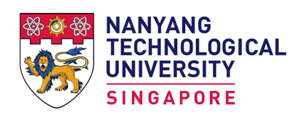 &nbsp;&nbsp;&nbsp;
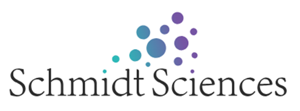

<i>⚙ AgentForge · Hands-on Workshop on AI Agents as Scientific Research Assistants</i>
</div>